In [1]:
import pandas as pd

df = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print(df["Churn"].value_counts())

No     5174
Yes    1869
Name: Churn, dtype: int64


In [7]:
data = df.copy()

In [8]:
print(data.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [9]:
print(data["TotalCharges"].head(20))

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object


In [12]:
print(data["TotalCharges"].dtype)

object


In [13]:
print(data["TotalCharges"].isnull().sum())

0


In [14]:
print((data["TotalCharges"] == " ").sum())

11


In [19]:
print(data.select_dtypes(include="object").columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [28]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [29]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [30]:
encoded_data = encoder.fit_transform(X[categorical_cols])

In [31]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

In [32]:
X_encoded = pd.concat(
    [
        X[numerical_cols],
        encoded_df
    ],
    axis=1
)

In [33]:
print(X_encoded.head())
print(X_encoded.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Female  \
0              0       1           29.85         29.85            1.0   
1              0      34           56.95       1889.50            0.0   
2              0       2           53.85        108.15            0.0   
3              0      45           42.30       1840.75            0.0   
4              0       2           70.70        151.65            1.0   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  Dependents_Yes  ...  \
0          0.0         0.0          1.0            1.0             0.0  ...   
1          1.0         1.0          0.0            1.0             0.0  ...   
2          1.0         1.0          0.0            1.0             0.0  ...   
3          1.0         1.0          0.0            1.0             0.0  ...   
4          0.0         1.0          0.0            1.0             0.0  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0               

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 45)
X_test: (1409, 45)
y_train: (5634,)
y_test: (1409,)


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
scaler.fit_transform(X_train)

array([[-0.44177295,  0.10237124, -0.52197565, ..., -0.52380561,
         1.40690298, -0.54384572],
       [-0.44177295, -0.71174346,  0.33747781, ..., -0.52380561,
        -0.71078107,  1.83875676],
       [-0.44177295, -0.79315493, -0.80901319, ..., -0.52380561,
        -0.71078107,  1.83875676],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ..., -0.52380561,
        -0.71078107,  1.83875676],
       [-0.44177295, -0.34539184, -1.47766135, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [-0.44177295, -1.07809507, -1.46936546, ..., -0.52380561,
        -0.71078107,  1.83875676]])

In [38]:
scaler.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [-0.44177295,  0.34660565,  0.44532428, ...,  1.90910518,
        -0.71078107, -0.54384572],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [-0.44177295,  0.95719167, -1.50088982, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [-0.44177295,  1.60848343,  0.18317439, ..., -0.52380561,
        -0.71078107, -0.54384572]])

In [39]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 45)
(1409, 45)


In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model_lr = LogisticRegression(max_iter=1000)

In [42]:
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8076650106458482
Precision: 0.660436137071651
Recall   : 0.5668449197860963
F1 Score : 0.6100719424460431


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[926 109]
 [162 212]]


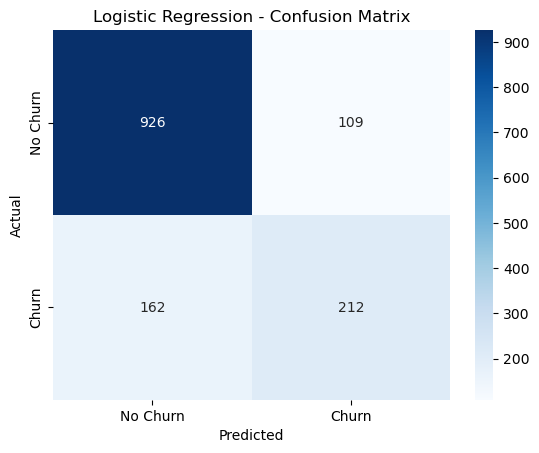

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [47]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [48]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.7984386089425124
Precision: 0.6347305389221557
Recall   : 0.5668449197860963
F1 Score : 0.5988700564971752


In [49]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [50]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.7856635911994322
Precision: 0.6232876712328768
Recall   : 0.48663101604278075
F1 Score : 0.5465465465465467


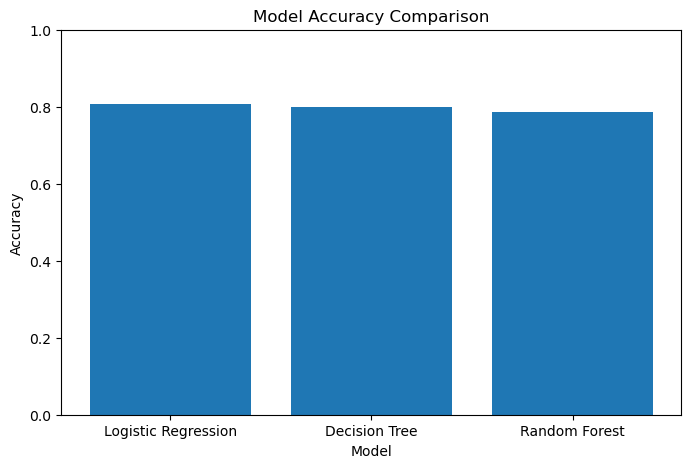

In [51]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy,
    accuracy_dt,
    accuracy_rf
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

In [52]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [53]:
import joblib

joblib.dump(model_lr, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

In [54]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


SyntaxError: invalid syntax (3737097518.py, line 1)

In [22]:
print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


In [24]:
print(y.value_counts())

0    5174
1    1869
Name: Churn, dtype: int64


In [26]:
print(X.shape)

(7043, 19)


In [27]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
X = X.drop("customerID", axis=1)

In [23]:
y = y.map({"No": 0, "Yes": 1})

In [20]:
for col in data.select_dtypes(include="object").columns:
    print("\n", col)
    print(data[col].unique())


 customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn
['No' 'Yes']


In [21]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [15]:
print(data[data["TotalCharges"] == " "][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218       0           19.70                 No
6670       0           73.35                 No
6754       0           61.90                 No


In [18]:
print(data.shape)

(7043, 21)


In [17]:
print(data["TotalCharges"].isnull().sum())

0


In [16]:
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data["TotalCharges"] = data["TotalCharges"].fillna(0)

In [2]:
print(df.shape)

(7043, 21)


In [3]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
